In [1]:
import pandas as pd
import numpy as np 
import json
from data.asset import Asset
from data.processor import calculate_features
from strategy.generator import strategyname, MeanReversionStrategy, TrendFollowingStrategy
from performance.backtest import Backtester
from performance.metrics import max_drawdown, buy_and_hold

In [2]:
with open("config.json") as f:
    config = json.load(f)

In [3]:

stock = Asset(ticker=config["ticker"], start=config["start"], end=config["end"])


In [4]:
stock.load_price_data()
stock.data = calculate_features(stock.data)

    lb_stat  lb_pvalue
1  3.273276   0.070417


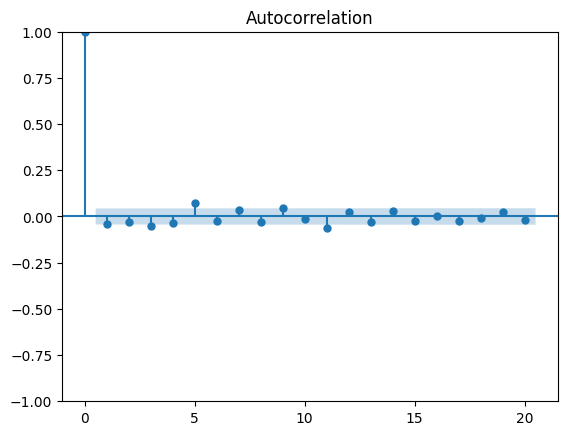

In [5]:
mean_rev_strat = MeanReversionStrategy(stock.data)
mean_rev_strat.run()

    lb_stat  lb_pvalue
1  3.273276   0.070417


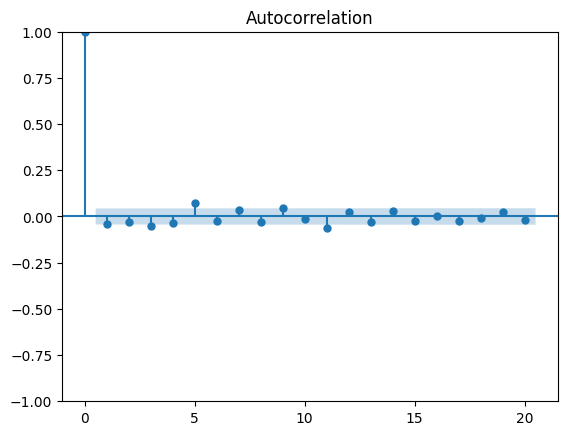

In [6]:
trend_follow_strat = TrendFollowingStrategy(stock.data)
trend_follow_strat.run()

In [7]:
Backtester(stock.data, strategyname.MEAN_REVERSION).test()

mean_reversion


{'# winning trades': np.int64(1010),
 '# losing trades': np.int64(990),
 '# neutral trades': np.int64(26),
 '# na trades': np.int64(2),
 '# total trades': np.int64(2026),
 'win_rate': np.float64(0.49851924975320827)}

In [8]:
Backtester(stock.data, strategyname.TREND_FOLLOWING).test()

trend_following


{'# winning trades': np.int64(990),
 '# losing trades': np.int64(1010),
 '# neutral trades': np.int64(26),
 '# na trades': np.int64(2),
 '# total trades': np.int64(2026),
 'win_rate': np.float64(0.4886475814412636)}

{'max_drawdown': np.float64(-0.5544467258804938),
 'peak_date': Timestamp('2012-09-07 00:00:00+0530', tz='Asia/Kolkata'),
 'trough_date': Timestamp('2018-05-04 00:00:00+0530', tz='Asia/Kolkata')}

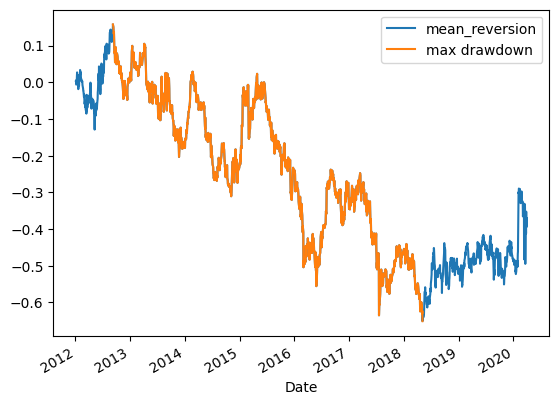

In [9]:
max_drawdown(stock.data, strategyname.MEAN_REVERSION)

{'max_drawdown': np.float64(-0.3032338107289435),
 'peak_date': Timestamp('2018-05-04 00:00:00+0530', tz='Asia/Kolkata'),
 'trough_date': Timestamp('2020-02-06 00:00:00+0530', tz='Asia/Kolkata')}

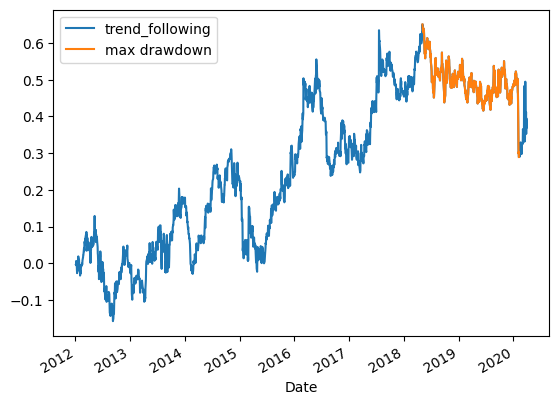

In [10]:
max_drawdown(stock.data, strategyname.TREND_FOLLOWING)

np.float64(0.33839802155019005)

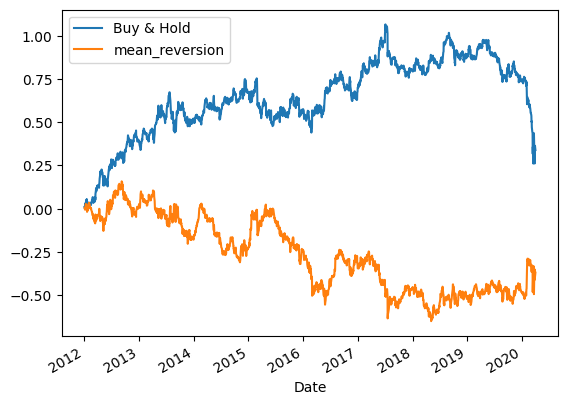

In [11]:
buy_and_hold(stock.data, strategyname.MEAN_REVERSION)

np.float64(0.33839802155019005)

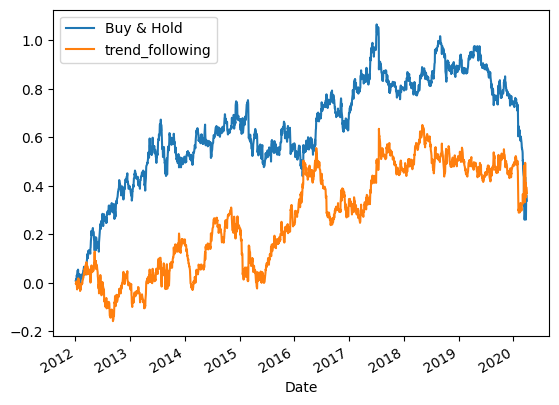

In [12]:
buy_and_hold(stock.data, strategyname.TREND_FOLLOWING)